### Check to make sure GPU is available

In [60]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 6796287925280397005
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 5833228288
locality {
  bus_id: 1
  links {
  }
}
incarnation: 11398690541656336916
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9"
xla_global_id: 416903419
]


I0000 00:00:1760378877.268376   18505 gpu_device.cc:2022] Created device /device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


### Import necessary libraries

In [61]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt

## All data (big and small circles together)

### Read in and visualize raw dataframe

In [395]:
raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data.csv")

raw_df.set_index('subject', inplace=True)

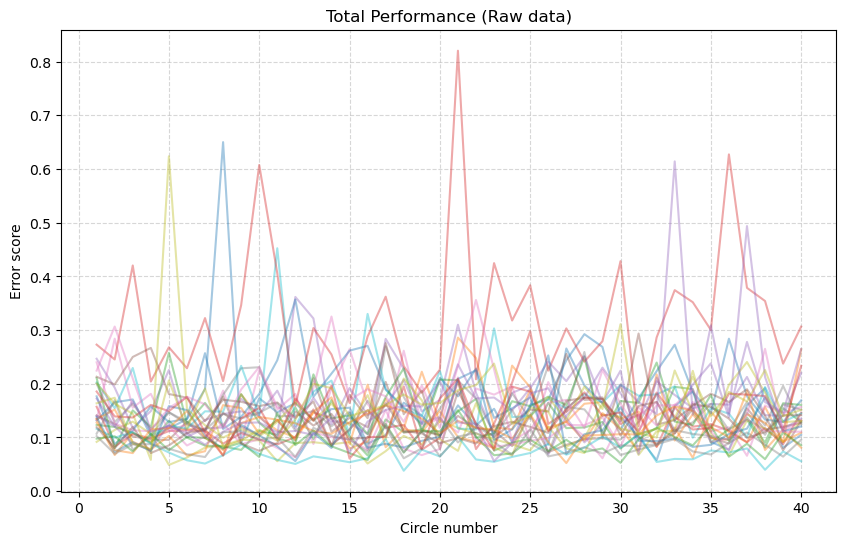

In [396]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(1, 41), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Clean up data by removing outliers and visualize

In [397]:
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# Replace values with NaN if they’re more than 1 standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) >2.5)

# fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)

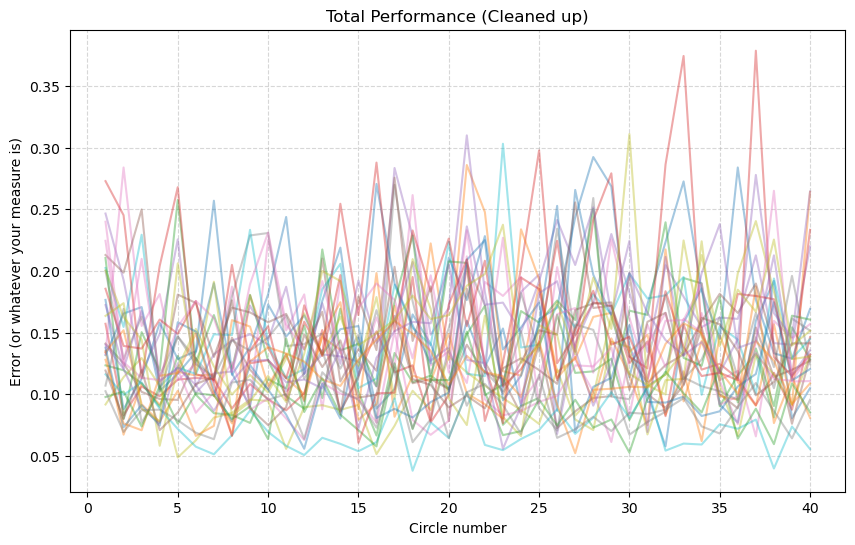

In [398]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(1, 41), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number")
plt.ylabel("Error (or whatever your measure is)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Calculate the slope for various window sizes in the data

In [399]:
window_sizes = [4, 8, 16, 20, 40] # each window contains the same number of big and small circles
#window_sizes = [8] # each window contains the same number of big and small circles

slopes_dict = {}  # to store slopes for each window

for window in window_sizes:
    all_slopes = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            window_vals = errors[start:start+window]
            x = np.arange(window)
            
            # Skip flat windows (all values identical)
            if np.all(window_vals == window_vals[0]):
                slope = 0.0
            else:
                slope = np.polyfit(x, window_vals, 1)[0]
            
            all_slopes.append(slope)
    
    slopes_dict[window] = np.array(all_slopes)

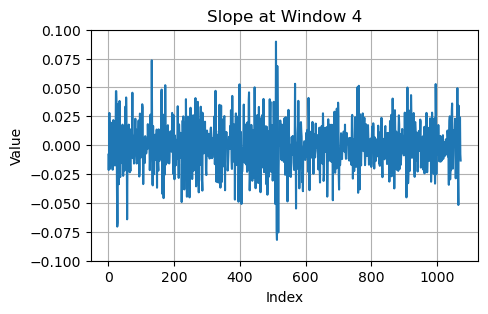

Number of slope samples: 1073


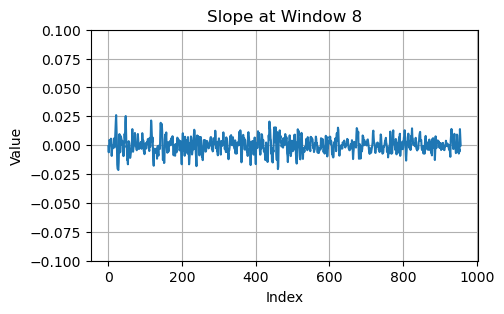

Number of slope samples: 957


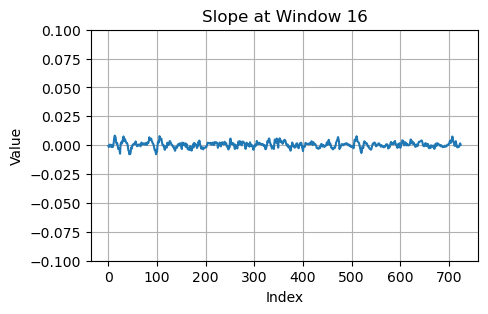

Number of slope samples: 725


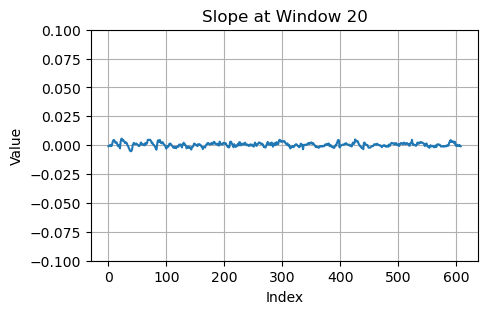

Number of slope samples: 609


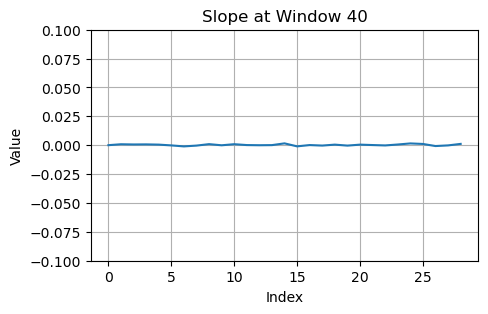

Number of slope samples: 29


In [401]:
for window, slope in slopes_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(slope)), slope)
    plt.title(f'Slope at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-0.1, 0.1)
    plt.grid(True)
    plt.show()
    print("Number of slope samples:", len(slope))

### Ruptures to detect change

Subject 1 change points: [19, 21]


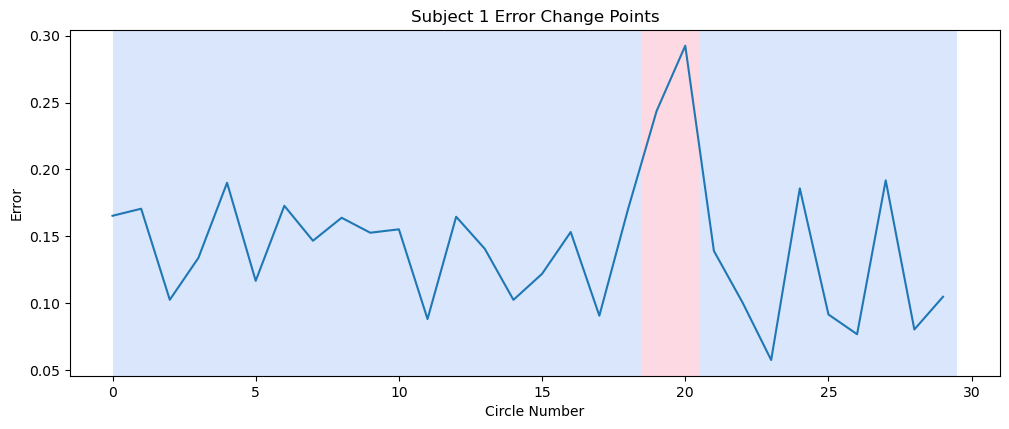

Subject 2 change points: [13, 16, 20, 23, 25, 28]


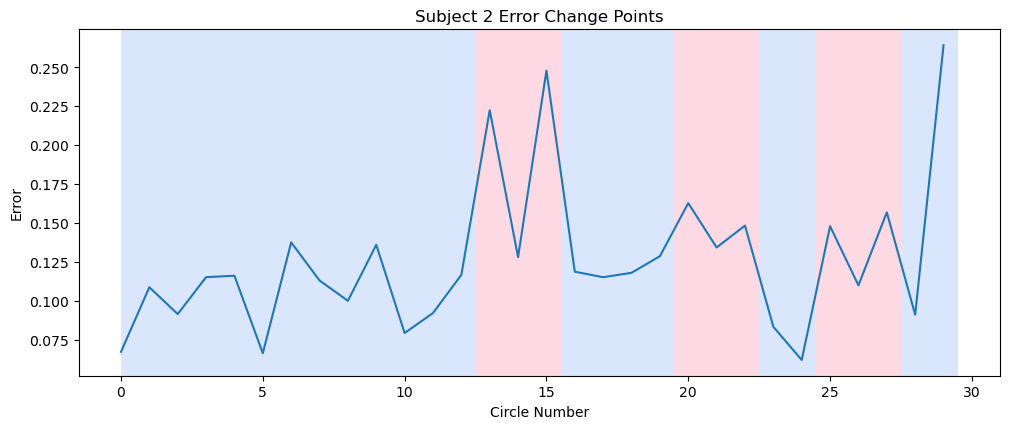

Subject 3 change points: [8, 10, 28]


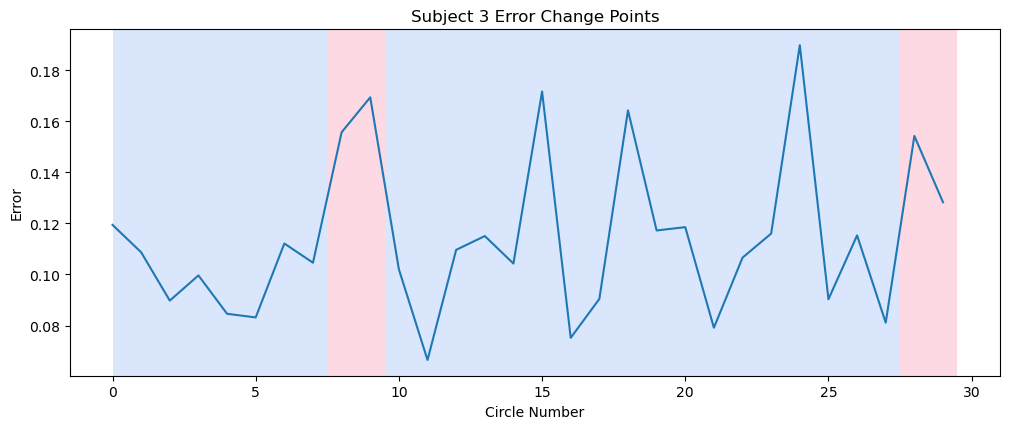

Subject 4 change points: [10, 13, 16]


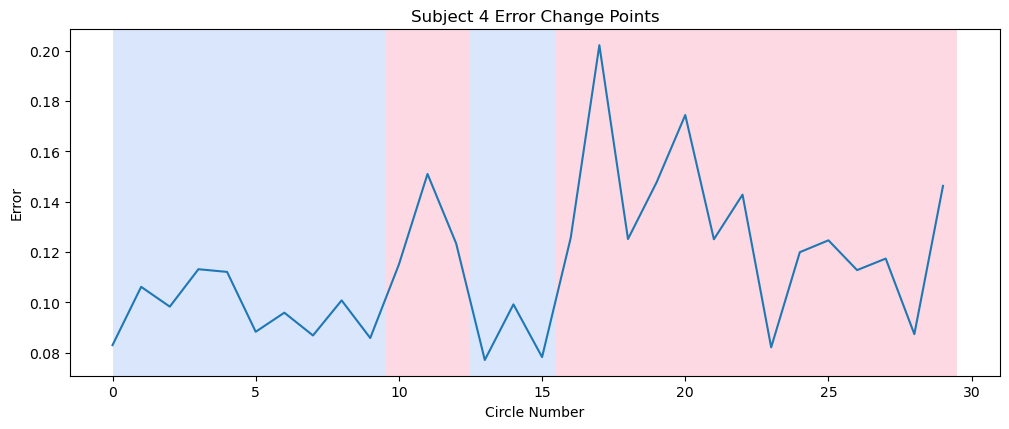

Subject 5 change points: [12]


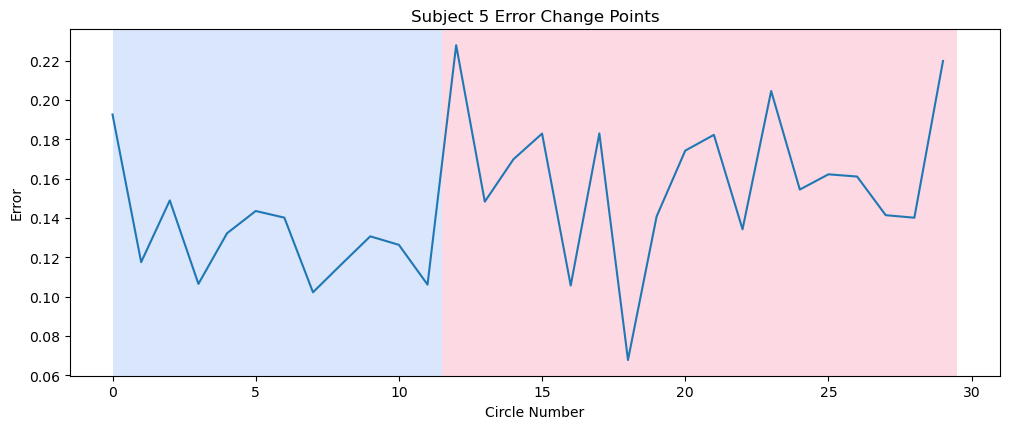

Subject 6 change points: [11, 17, 20, 27]


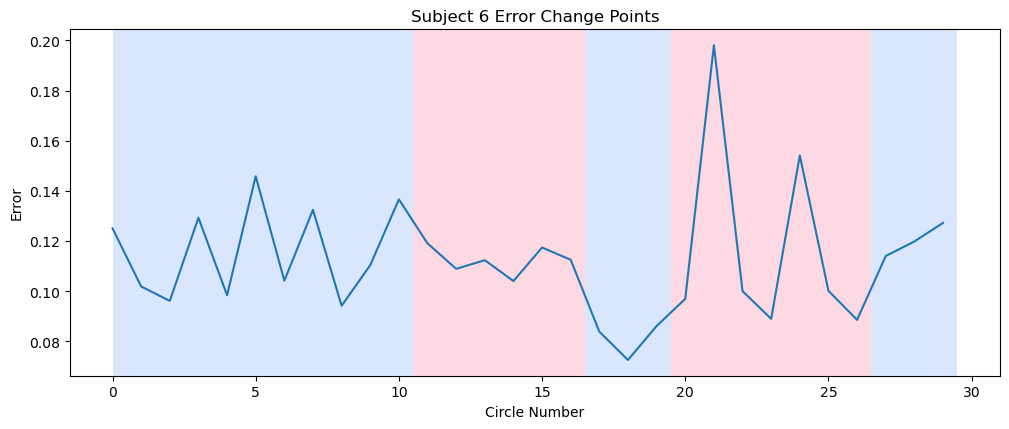

Subject 7 change points: [3, 5, 10, 13, 15, 19]


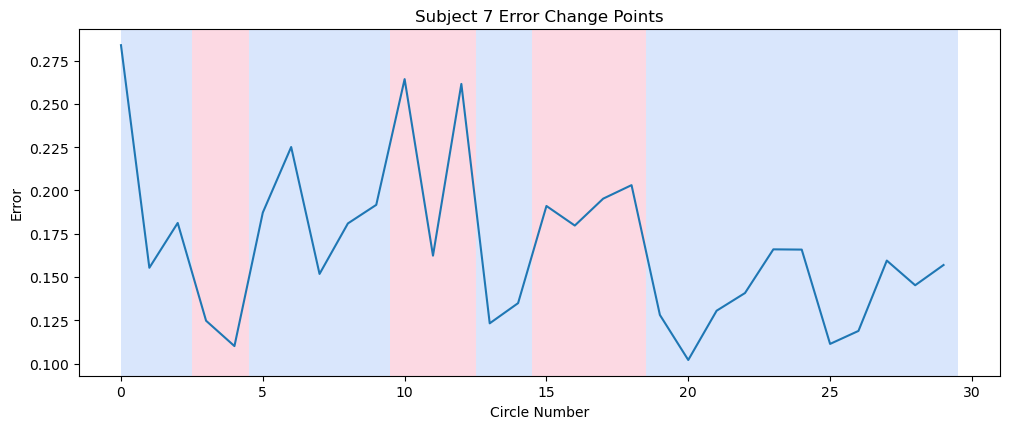

Subject 8 change points: []


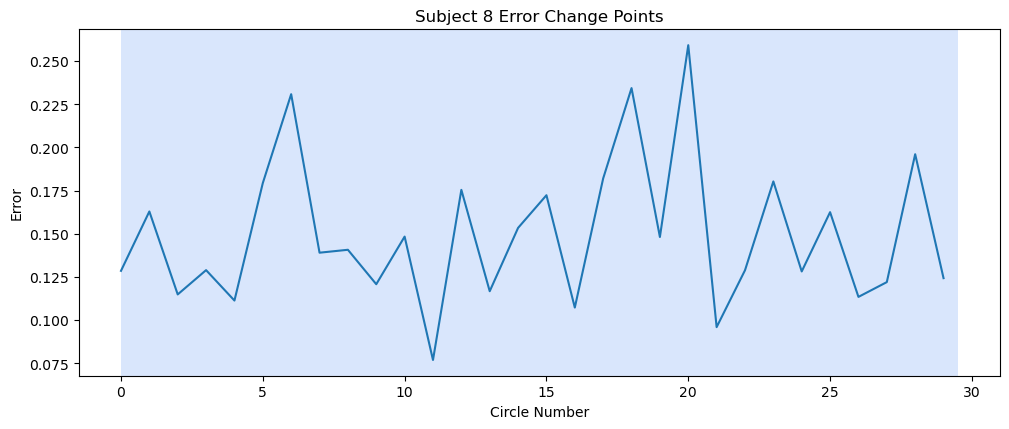

Subject 9 change points: [3, 14]


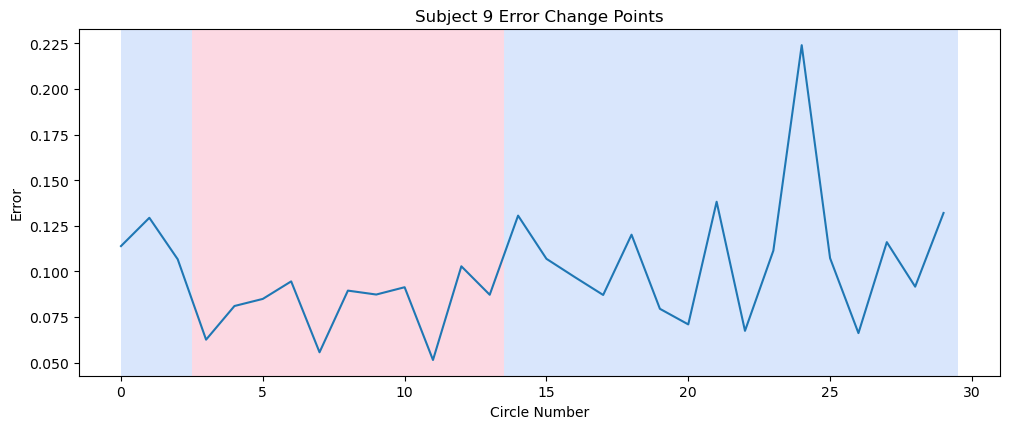

Subject 10 change points: [18, 24]


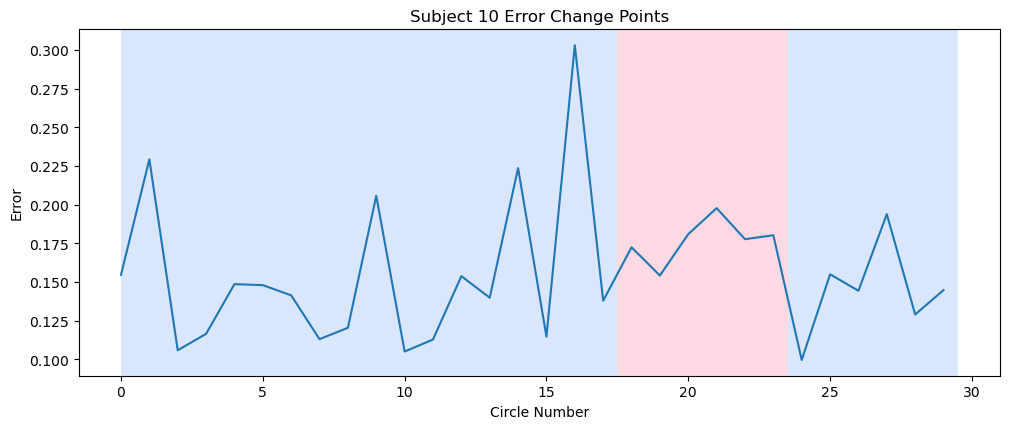

Subject 11 change points: [9, 12]


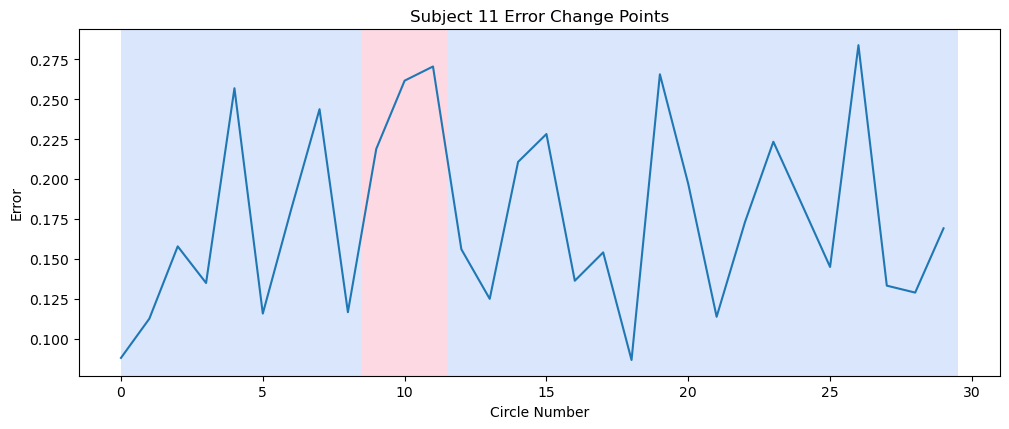

Subject 12 change points: []


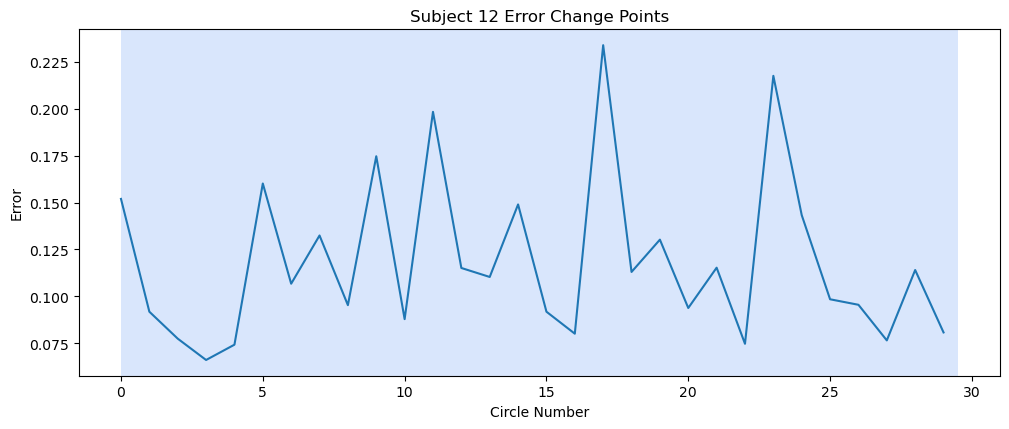

Subject 13 change points: [17, 26, 28]


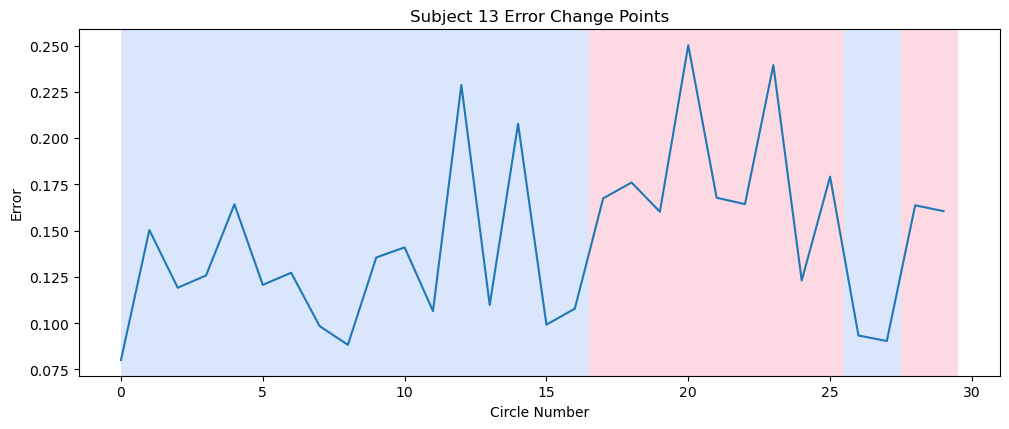

Subject 14 change points: [9, 16, 18, 21]


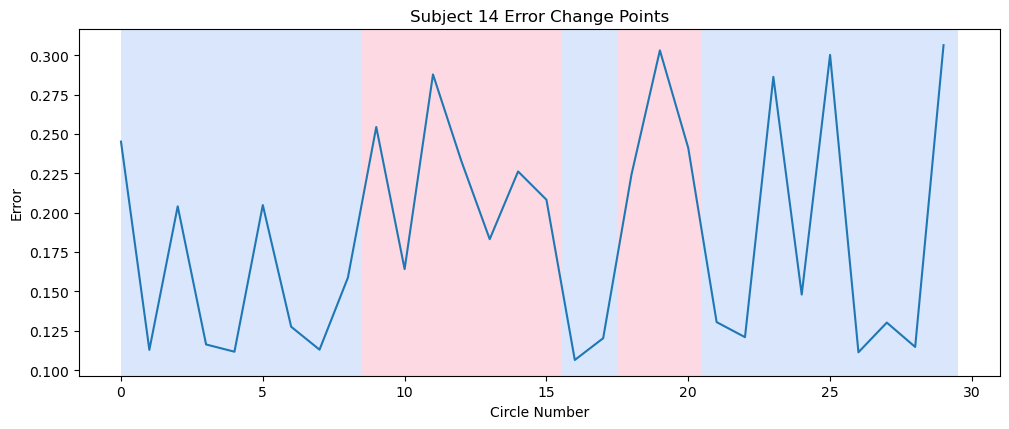

Subject 15 change points: [6, 18, 26]


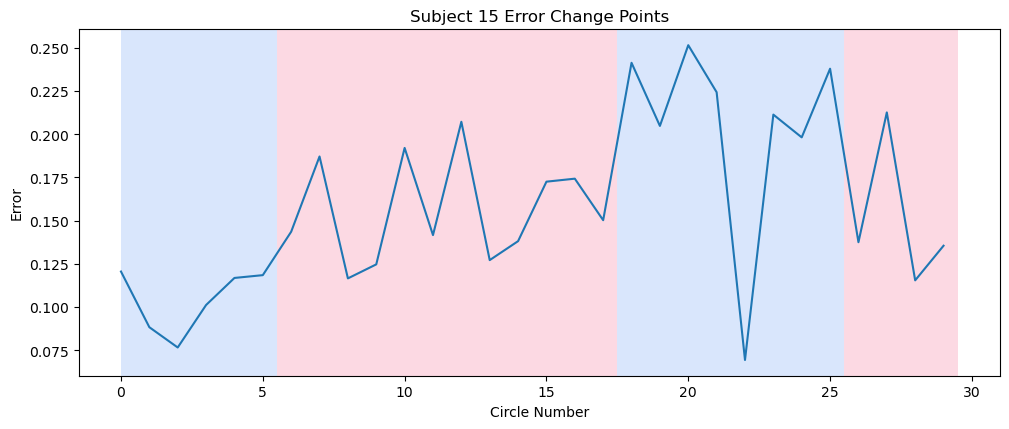

Subject 16 change points: [2]


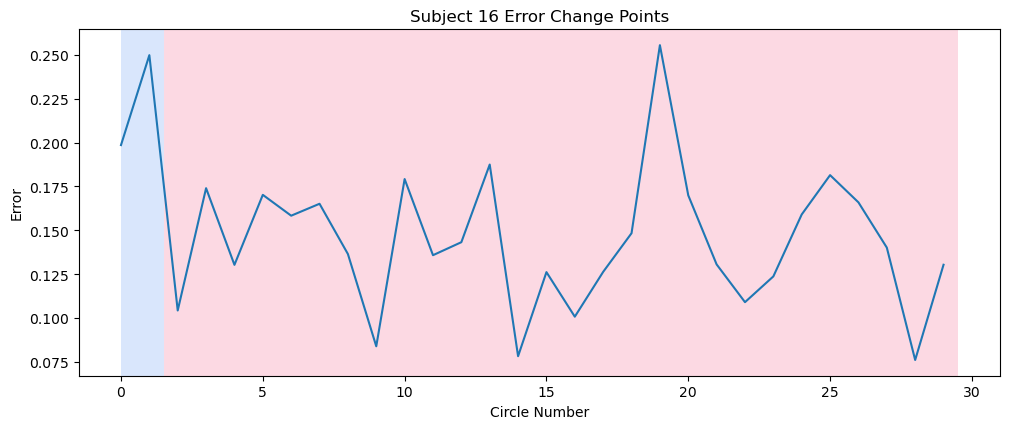

Subject 17 change points: [6, 19]


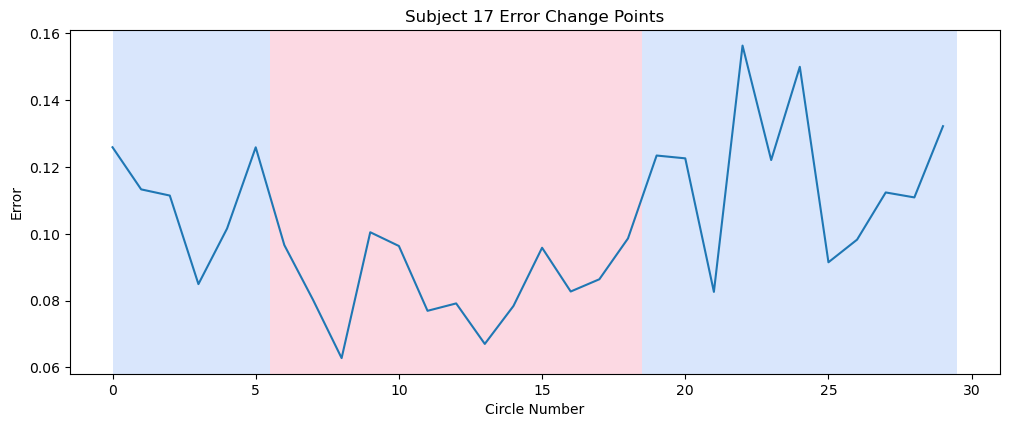

Subject 18 change points: [19, 21, 24, 28]


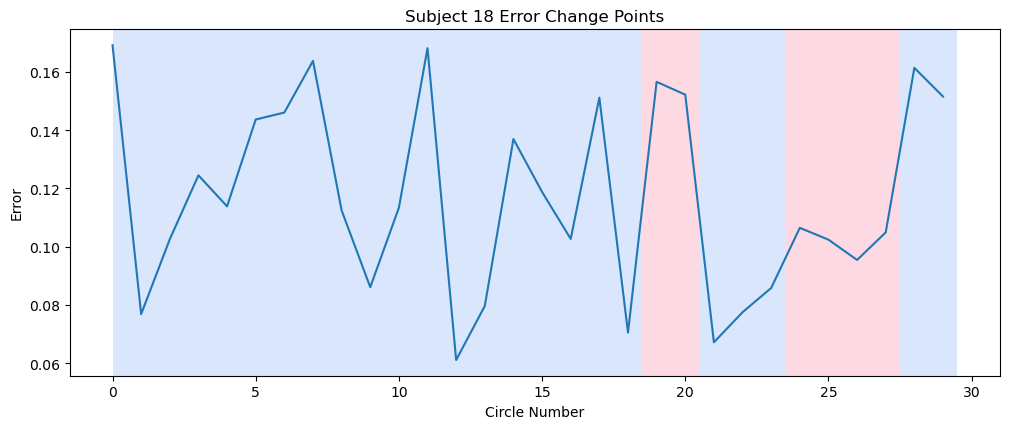

Subject 19 change points: [4, 8, 14, 26, 28]


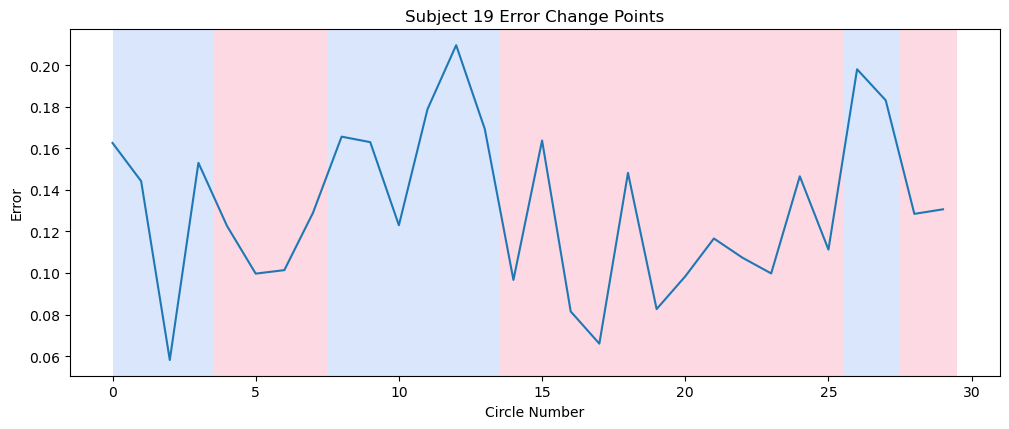

Subject 20 change points: [3, 18, 23]


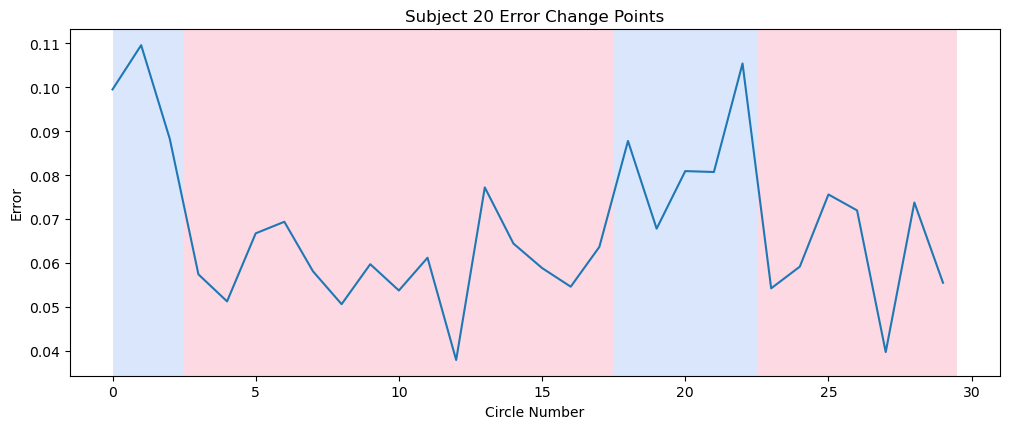

Subject 21 change points: [26]


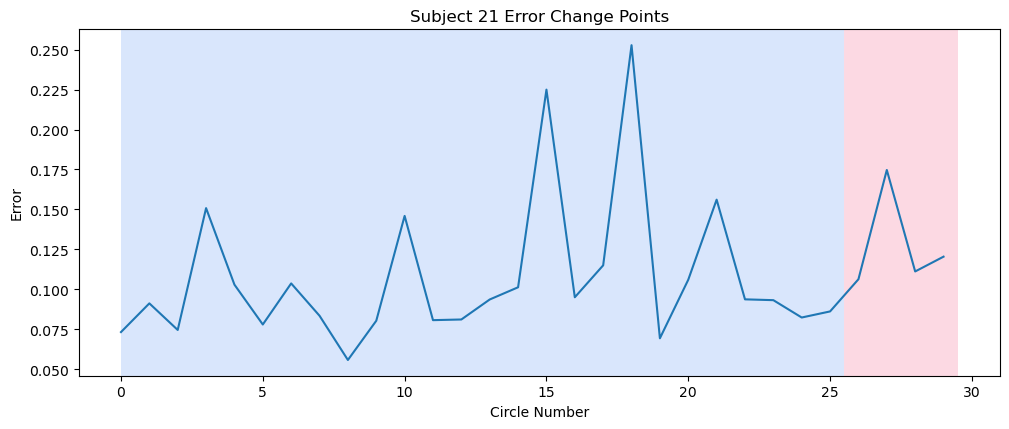

Subject 22 change points: [6, 14, 23, 25]


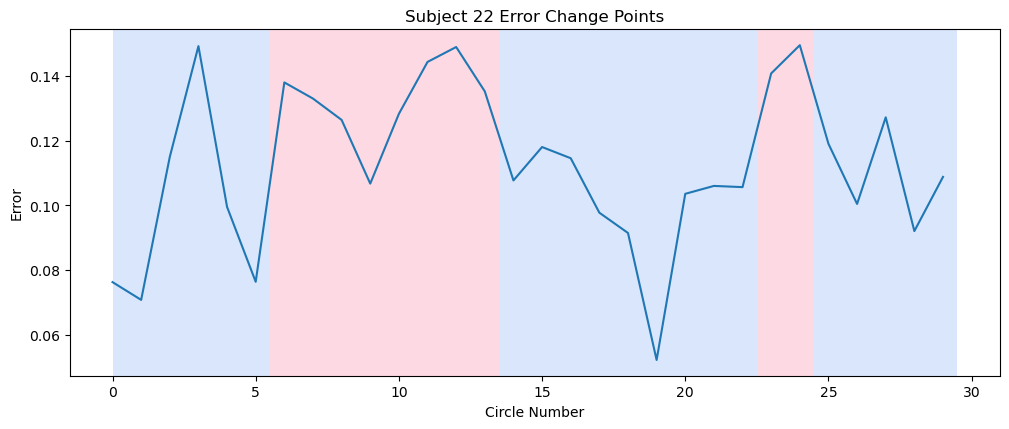

Subject 23 change points: [5, 13, 16, 22, 26, 28]


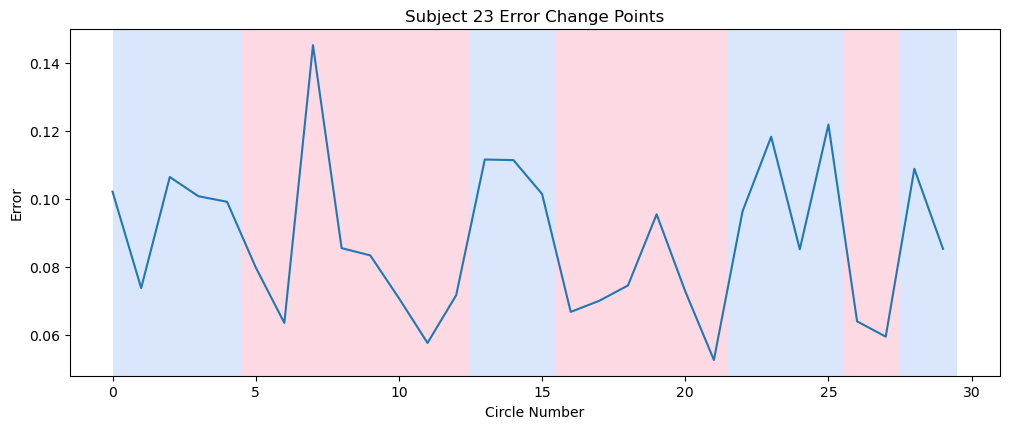

Subject 24 change points: []


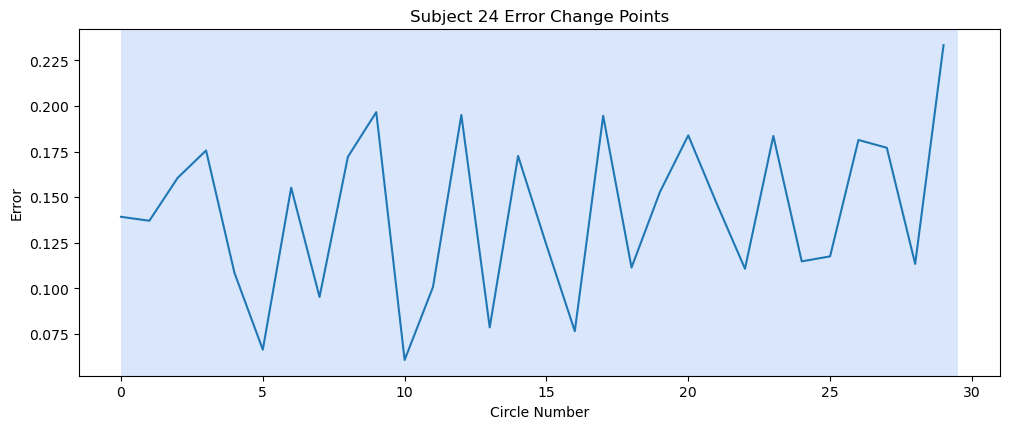

Subject 25 change points: [12, 14, 22]


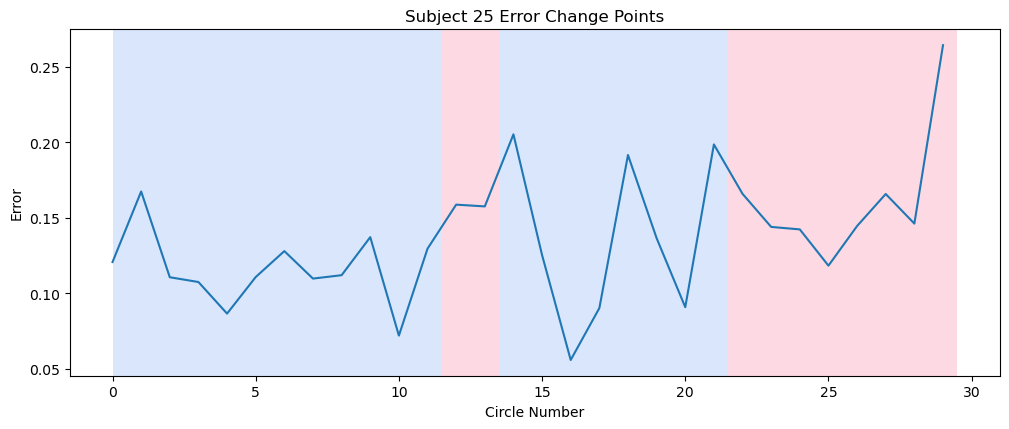

Subject 26 change points: [8, 10, 19, 26]


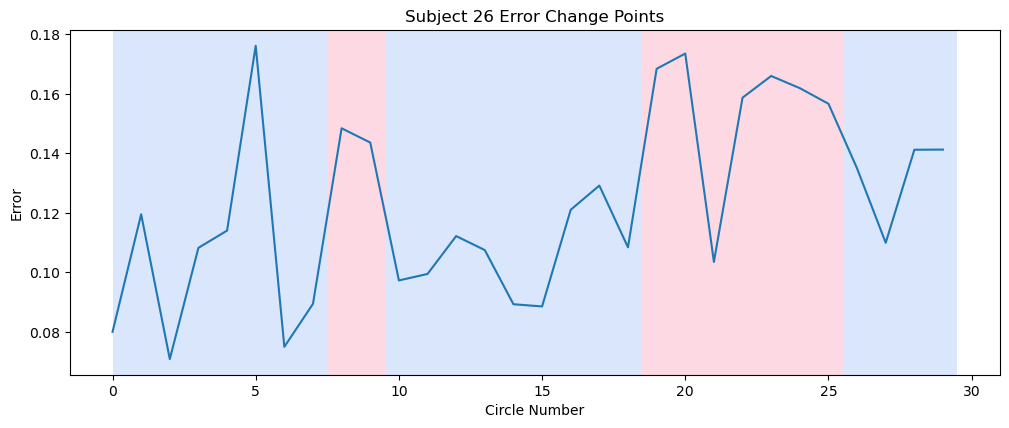

Subject 27 change points: [2, 25]


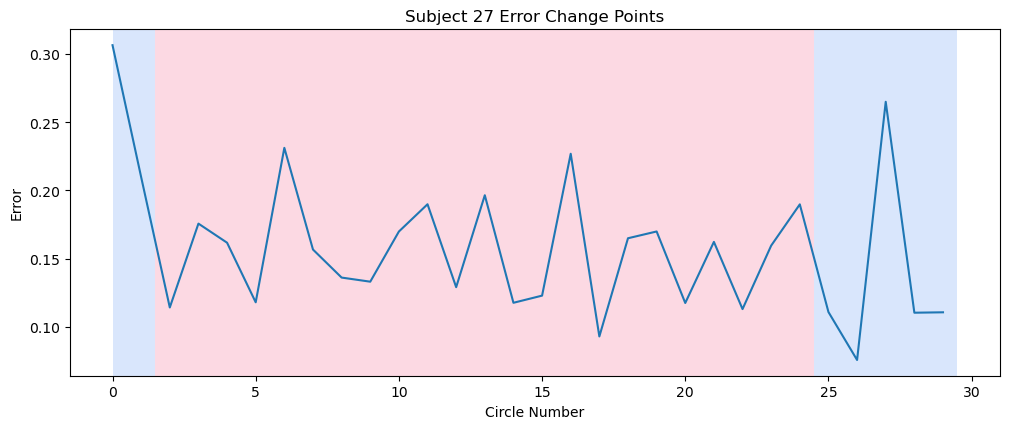

Subject 28 change points: [5, 11, 13, 17, 20]


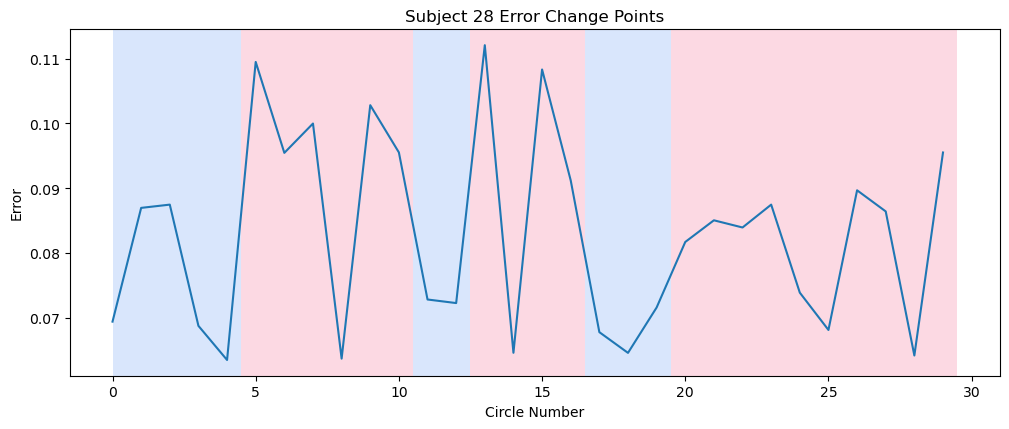

Subject 29 change points: [8]


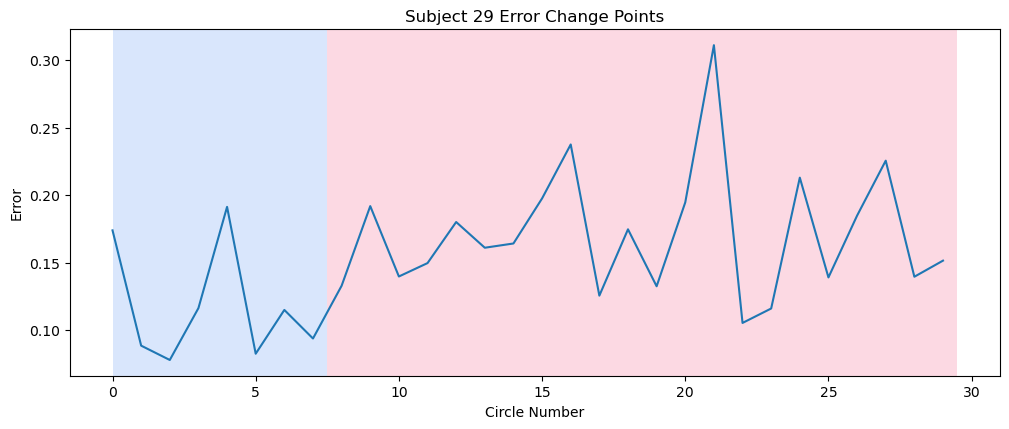

In [368]:
for subj in range(len(df_clean)): # iterature through every subject
    signal = small_clean.iloc[subj].values  # given subject’s 40 error values

    # Choose model and penalty (tune this)
    model = "rbf"   # for nonlinear patterns
    algo = rpt.Pelt(model=model, jump=1).fit(signal)

    # Change the penalty value to control sensitivity
    change_points = algo.predict(pen=1)

    true_change_points = change_points[:-1] # take off 40 from the end

    print(f"Subject {subj+1} change points:", true_change_points)

    # Plot
    rpt.display(signal, change_points, figsize=(10, 4))
    plt.title(f"Subject {subj+1} Error Change Points")
    plt.xlabel("Circle Number")
    plt.ylabel("Error")
    plt.show()

Total change points: [8, 30]


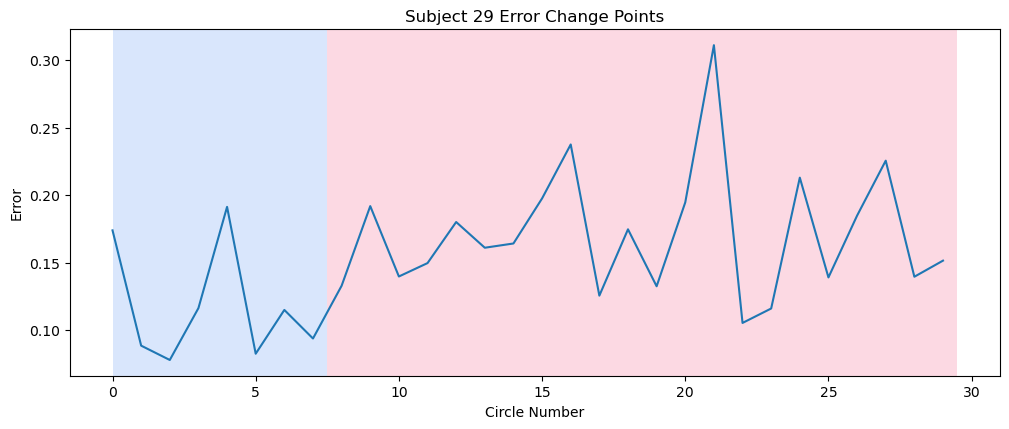

In [369]:
print(f"Total change points:", change_points)

algo_total = rpt.Window(model='l2').fit(df_clean.values)
result_total = algo_total.predict(pen=20)

# Plot
rpt.display(signal, change_points, figsize=(10, 4))
plt.title(f"Subject {subj+1} Error Change Points")
plt.xlabel("Circle Number")
plt.ylabel("Error")
plt.show()


### Gaussian Mixture to determine slope thresholds

In [ ]:
# from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
# from scipy.stats import norm

# def find_intersection(mu1, sigma1, mu2, sigma2):
#     # Numerical intersection of two 1D Gaussians
#     x = np.linspace(min(mu1, mu2) - 3*max(sigma1, sigma2),
#                     max(mu1, mu2) + 3*max(sigma1, sigma2), 10000)
#     p1 = norm.pdf(x, mu1, sigma1)
#     p2 = norm.pdf(x, mu2, sigma2)
#     idx = np.argwhere(np.diff(np.sign(p1 - p2))).flatten()
#     return x[idx]

# thresholds = {}
# gmm_results = {}

# for window, slopes in slopes_dict.items():
#     slopes_reshaped = slopes.reshape(-1, 1)
#     gmm = GaussianMixture(n_components=3, n_init=100, covariance_type='full', tol=.1)
#     gmm.fit(slopes_reshaped)
    
#     means = np.sort(gmm.means_.flatten())
#     sigmas = np.sqrt(np.sort(gmm.covariances_.flatten()))
    
#     t1 = find_intersection(means[0], sigmas[0], means[1], sigmas[1])[0]
#     t2 = find_intersection(means[1], sigmas[1], means[2], sigmas[2])[0]
    
#     thresholds[window] = {"learning_nothing": t1, "nothing_fatigue": t2}
#     gmm_results[window] = {"means": means, "sigmas": sigmas, "slopes": slopes}

# # Display thresholds per window
# for w, t in thresholds.items():
#     print(f"Window {w}: Learning–Nothing = {t['learning_nothing']:.4f}, Nothing–Fatigue = {t['nothing_fatigue']:.4f}")


Window 8: Learning–Nothing = -0.0038, Nothing–Fatigue = 0.0038


### Gaussian Mixture take 2

In [402]:
from sklearn.mixture import GaussianMixture
import numpy as np

thresholds = {}
gmm_results = {}

for window, slopes in slopes_dict.items():
    slopes_reshaped = slopes.reshape(-1, 1)
    
    # Fit GMM
    gmm = GaussianMixture(n_components=3, n_init=100, covariance_type='full', tol=.001)
    gmm.fit(slopes_reshaped)
    
    # Get sorted means and stds
    means = np.sort(gmm.means_.flatten())
    sigmas = np.sqrt(np.sort(gmm.covariances_.flatten()))
    
    # Use component means as thresholds
    t1 = means[0]  # "learning_nothing"
    t2 = means[2]  # "nothing_fatigue"
    
    thresholds[window] = {
        "learning_nothing": t1,
        "nothing_fatigue": t2,
    }
    
    gmm_results[window] = {"means": means, "sigmas": sigmas, "slopes": slopes}

# Display thresholds per window
for w, t in thresholds.items():
    print(f"Window {w}: Learning–Nothing = {t['learning_nothing']:.4f}, Nothing–Fatigue = {t['nothing_fatigue']:.4f}")


Window 4: Learning–Nothing = -0.0200, Nothing–Fatigue = 0.0194
Window 8: Learning–Nothing = -0.0064, Nothing–Fatigue = 0.0068
Window 16: Learning–Nothing = -0.0016, Nothing–Fatigue = 0.0035
Window 20: Learning–Nothing = -0.0004, Nothing–Fatigue = 0.0021
Window 40: Learning–Nothing = 0.0003, Nothing–Fatigue = 0.0003


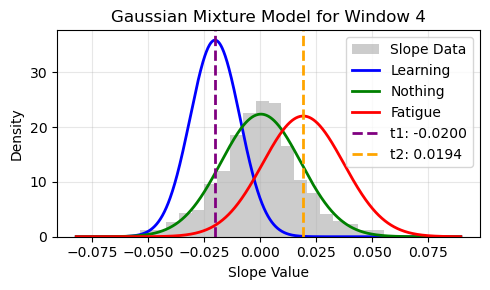

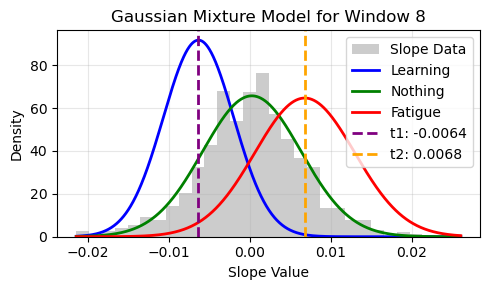

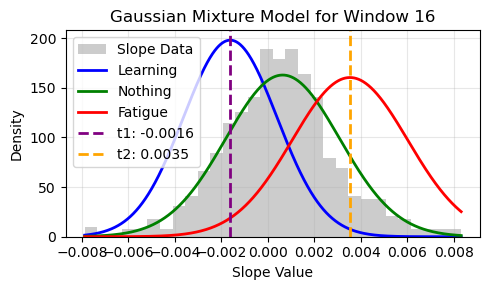

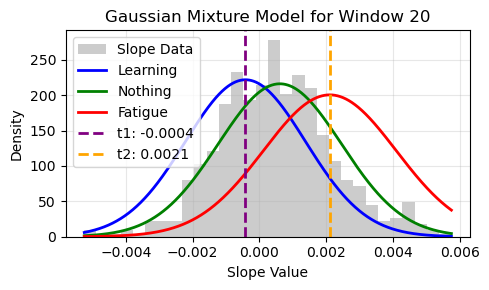

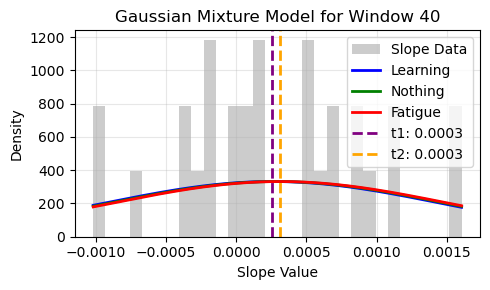

In [403]:
# --- Now plot for windows using the already computed results ---
for window in window_sizes: 
    window_to_plot = window
    res = gmm_results[window_to_plot]
    means = res["means"]
    sigmas = res["sigmas"]
    slopes = res["slopes"]

    x = np.linspace(slopes.min(), slopes.max(), 1000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    t1 = thresholds[window_to_plot]["learning_nothing"]
    t2 = thresholds[window_to_plot]["nothing_fatigue"]

    plt.figure(figsize=(5,3))
    plt.hist(slopes, bins=30, density=True, alpha=0.4, color='gray', label='Slope Data')
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)
    plt.axvline(t1, color='purple', linestyle='--', lw=2, label=f't1: {t1:.4f}')
    plt.axvline(t2, color='orange', linestyle='--', lw=2, label=f't2: {t2:.4f}')
    plt.title(f"Gaussian Mixture Model for Window {window_to_plot}")
    plt.xlabel("Slope Value")
    plt.ylabel("Density")
    # plt.xlim(-0.05, 0.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### Figure out if slopes calculated are statistically significant
#### H0 = The slope at or beyond the calculated threshold is due to random variation
#### H1 = The slope at or beyond the calculated threshold is due learning or fatigue

In [404]:
from scipy import stats
import statistics
from colorama import Fore

for w, t in thresholds.items():
    print(Fore.CYAN + f"Window {w}: mean slope is {statistics.mean(slopes_dict[w])}")
    t_stat, p_value = stats.ttest_1samp(slopes_dict[w], t['learning_nothing'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Learning–Nothing = {t['learning_nothing']:.4f} is statistically significant with a p-value of {p_value}") 
    else:
        print(Fore.RED + f"Learning–Nothing = {t['learning_nothing']:.4f} is NOT statistically significant with a p-value of {p_value}")
    t_stat, p_value = stats.ttest_1samp(slopes_dict[w], t['nothing_fatigue'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Nothing–Fatigue = {t['nothing_fatigue']:.4f} is statistically significant with a p-value of {p_value}")
    else:
        print(Fore.RED + f"Nothing–Fatigue = {t['nothing_fatigue']:.4f} is NOT statistically significant with a p-value of {p_value}")

Window 4: mean slope is -0.000210493697297295
Learning–Nothing = -0.0200 is statistically significant with a p-value of 5.9980737042679296e-170
Nothing–Fatigue = 0.0194 is statistically significant with a p-value of 3.78423941667819e-167
Window 8: mean slope is 0.00023208500791162362
Learning–Nothing = -0.0064 is statistically significant with a p-value of 5.427380319841455e-150
Nothing–Fatigue = 0.0068 is statistically significant with a p-value of 4.256576250577896e-148
Window 16: mean slope is 0.0004658307865801239
Learning–Nothing = -0.0016 is statistically significant with a p-value of 2.8937356038657077e-87
Nothing–Fatigue = 0.0035 is statistically significant with a p-value of 2.49472828717183e-150
Window 20: mean slope is 0.00047904311907539507
Learning–Nothing = -0.0004 is statistically significant with a p-value of 1.6047857937081542e-33
Nothing–Fatigue = 0.0021 is statistically significant with a p-value of 1.6843221442221217e-86
Window 40: mean slope is 0.000273300149246296

In [411]:
window = 8  # size of sliding window
learning_threshold = thresholds[window]["learning_nothing"]  # slope threshold to classify changes - want to make this dynamic
print(f"Learning threshold: {learning_threshold}")

fatigue_threshold = thresholds[window]["nothing_fatigue"]
print(f"Fatigue threshold: {fatigue_threshold}")

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        # Linear regression: slope = change per trial
        slope = np.polyfit(x, window_vals, 1)[0]
        
        if slope < learning_threshold:
            subject_modes.append("learning")
        elif slope > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # Pad the beginning so the mode array is same length as trials
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# Convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

Learning threshold: -0.006368872345238766
Fatigue threshold: 0.0067739757767110685


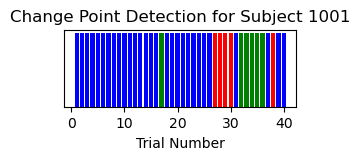

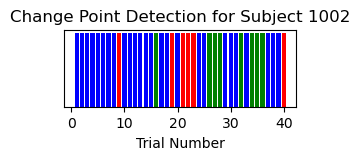

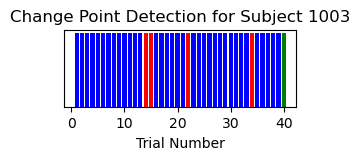

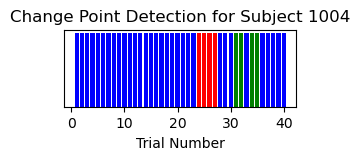

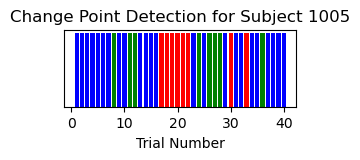

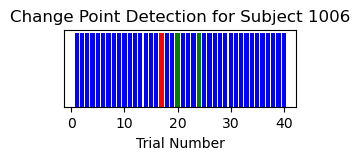

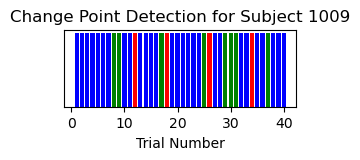

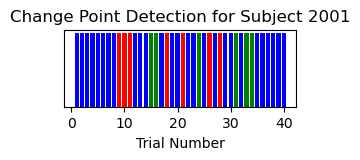

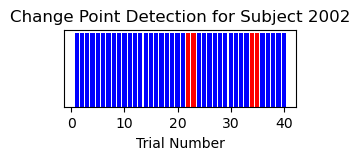

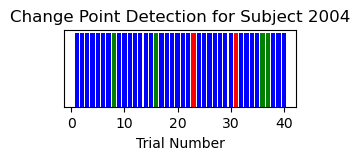

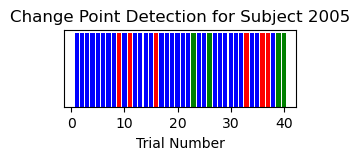

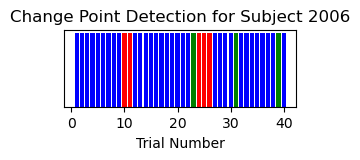

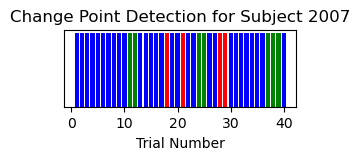

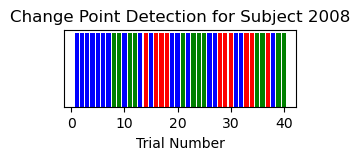

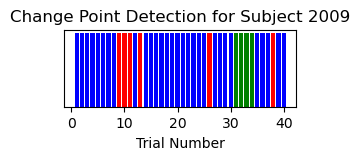

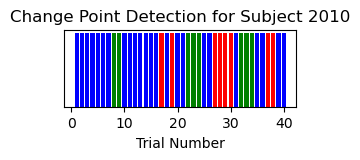

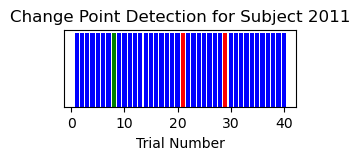

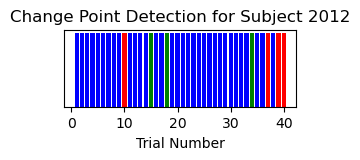

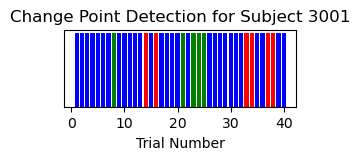

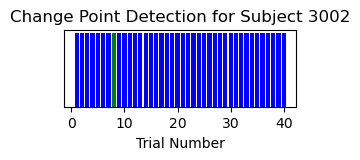

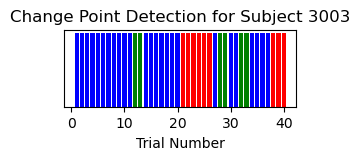

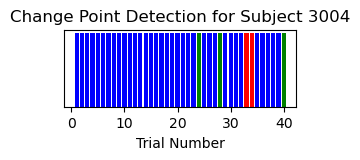

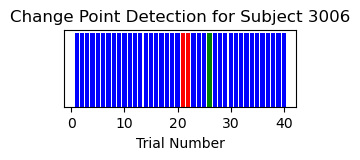

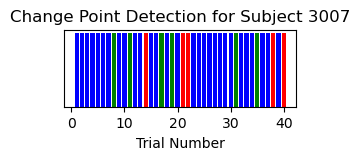

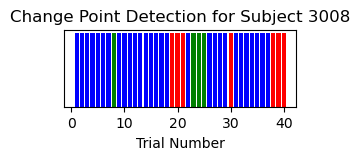

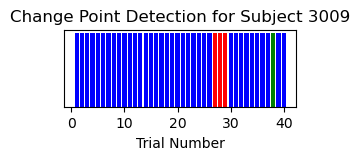

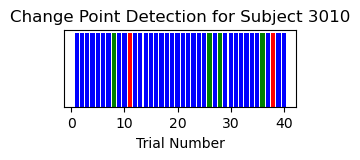

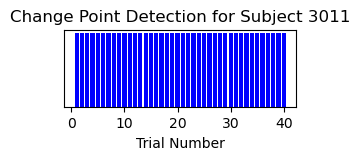

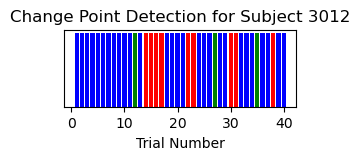

In [412]:
for i in range(0,29):
    subject = i
    colors = {"learning": "green", "nothing": "blue", "fatigued": "red"}
    # colors = {"learning": "green", "nothing": "blue"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,1))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {df_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()

## Clean up just for small circle data

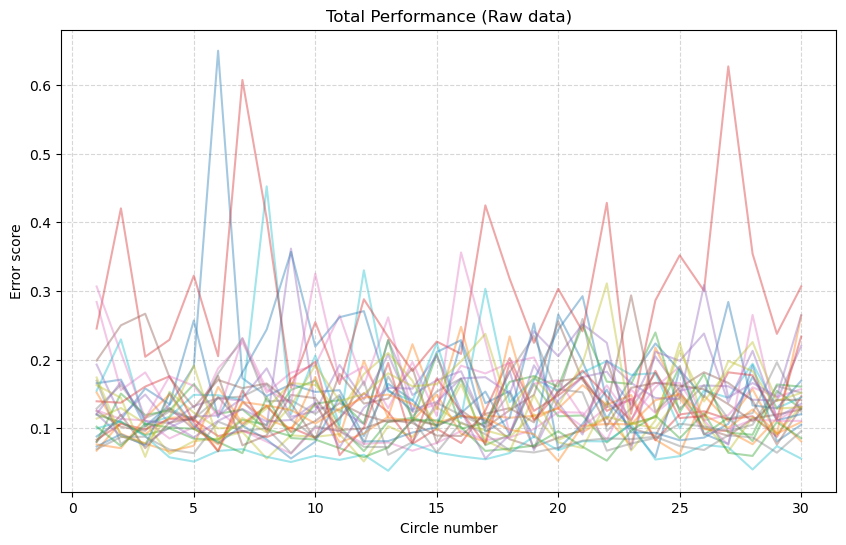

In [422]:
small_df = raw_df.drop(raw_df.filter(like='big', axis=1), axis=1)

plt.figure(figsize=(10, 6))
for i, row in small_df.iterrows():
    plt.plot(range(1, 31), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error score")
plt.grid(True, linestyle="--", alpha=0.5)

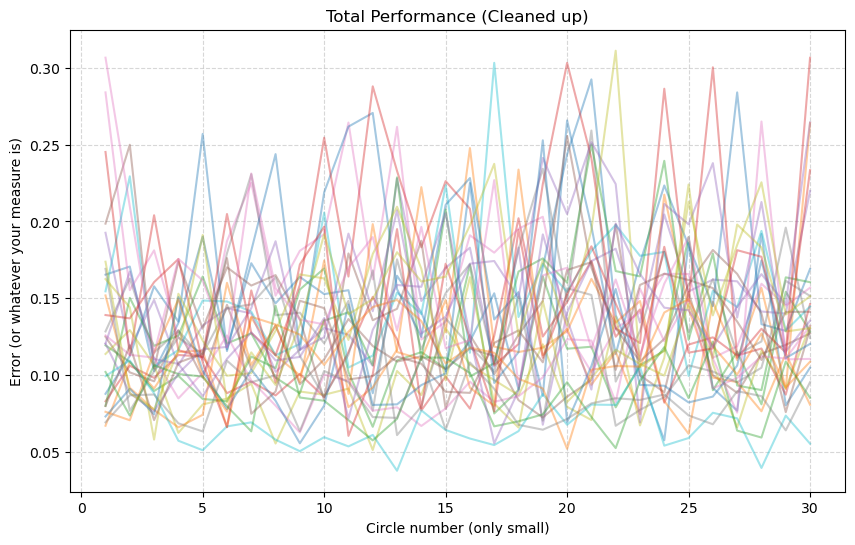

In [423]:
# Replace values with NaN if they’re more than 2.5 standard deviations from the mean
small_clean = small_df.mask(np.abs(z_scores) > 2.8)

# fill NaN with the median of that column instead of dropping
small_clean = small_clean.apply(lambda x: x.fillna(x.median()), axis=0)

plt.figure(figsize=(10, 6))
for i, row in small_clean.iterrows():
    plt.plot(range(1, 31), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number (only small)")
plt.ylabel("Error (or whatever your measure is)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [424]:
# window_sizes = [4, 8, 16, 20, 40] # each window contains the same number of big and small circles
window_sizes = [5, 10, 20] # each window contains the same number of big and small circles

slopes_dict = {}  # to store slopes for each window

for window in window_sizes:
    all_slopes = []
    for i, row in small_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            window_vals = errors[start:start+window]
            x = np.arange(window)
            
            # Skip flat windows (all values identical)
            if np.all(window_vals == window_vals[0]):
                slope = 0.0
            else:
                slope = np.polyfit(x, window_vals, 1)[0]
            
            all_slopes.append(slope)
    
    slopes_dict[window] = np.array(all_slopes)

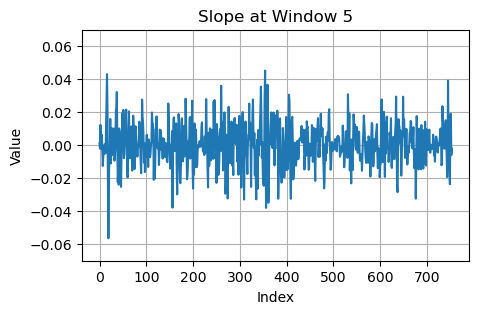

Number of slope samples: 754


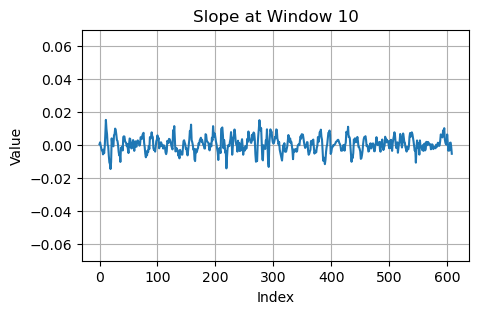

Number of slope samples: 609


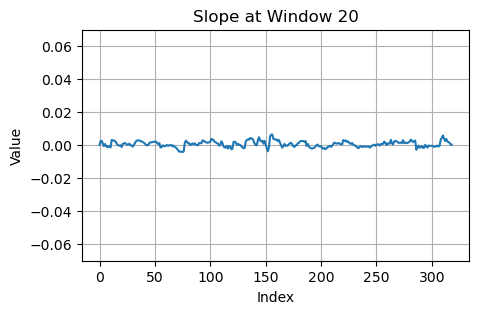

Number of slope samples: 319


In [425]:
for window, slope in slopes_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(slope)), slope)
    plt.title(f'Slope at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-0.07, 0.07)
    plt.grid(True)
    plt.show()
    print("Number of slope samples:", len(slope))

In [434]:
from sklearn.mixture import GaussianMixture
import numpy as np

thresholds = {}
gmm_results = {}

for window, slopes in slopes_dict.items():
    slopes_reshaped = slopes.reshape(-1, 1)
    
    # Fit GMM
    gmm = GaussianMixture(n_components=3, n_init=100, covariance_type='full', tol=.0001)
    gmm.fit(slopes_reshaped)
    
    # Get sorted means and stds
    means = np.sort(gmm.means_.flatten())
    sigmas = np.sqrt(np.sort(gmm.covariances_.flatten()))
    
    # Use component means as thresholds
    t1 = means[0]  # "learning_nothing"
    t2 = means[2]  # "nothing_fatigue"
    
    thresholds[window] = {
        "learning_nothing": t1,
        "nothing_fatigue": t2,
    }
    
    gmm_results[window] = {"means": means, "sigmas": sigmas, "slopes": slopes}

# Display thresholds per window
for w, t in thresholds.items():
    print(f"Window {w}: Learning–Nothing = {t['learning_nothing']:.4f}, Nothing–Fatigue = {t['nothing_fatigue']:.4f}")


Window 5: Learning–Nothing = -0.0118, Nothing–Fatigue = 0.0108
Window 10: Learning–Nothing = -0.0042, Nothing–Fatigue = 0.0054
Window 20: Learning–Nothing = 0.0006, Nothing–Fatigue = 0.0009


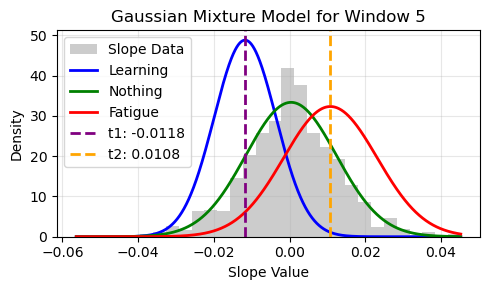

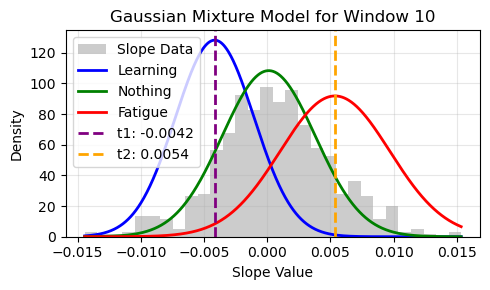

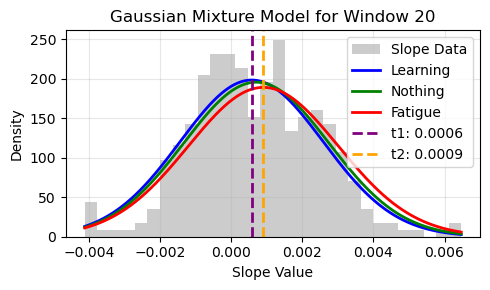

In [435]:
# --- Now plot for windows using the already computed results ---
for window in window_sizes: 
    window_to_plot = window
    res = gmm_results[window_to_plot]
    means = res["means"]
    sigmas = res["sigmas"]
    slopes = res["slopes"]

    x = np.linspace(slopes.min(), slopes.max(), 1000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    t1 = thresholds[window_to_plot]["learning_nothing"]
    t2 = thresholds[window_to_plot]["nothing_fatigue"]

    plt.figure(figsize=(5,3))
    plt.hist(slopes, bins=30, density=True, alpha=0.4, color='gray', label='Slope Data')
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)
    plt.axvline(t1, color='purple', linestyle='--', lw=2, label=f't1: {t1:.4f}')
    plt.axvline(t2, color='orange', linestyle='--', lw=2, label=f't2: {t2:.4f}')
    plt.title(f"Gaussian Mixture Model for Window {window_to_plot}")
    plt.xlabel("Slope Value")
    plt.ylabel("Density")
    # plt.xlim(-0.05, 0.05)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [436]:
from scipy import stats
import statistics
from colorama import Fore

for w, t in thresholds.items():
    print(Fore.CYAN + f"Window {w}: mean slope is {statistics.mean(slopes_dict[w])}")
    t_stat, p_value = stats.ttest_1samp(slopes_dict[w], t['learning_nothing'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Learning–Nothing = {t['learning_nothing']:.4f} is statistically significant with a p-value of {p_value}") 
    else:
        print(Fore.RED + f"Learning–Nothing = {t['learning_nothing']:.4f} is NOT statistically significant with a p-value of {p_value}")
    t_stat, p_value = stats.ttest_1samp(slopes_dict[w], t['nothing_fatigue'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Nothing–Fatigue = {t['nothing_fatigue']:.4f} is statistically significant with a p-value of {p_value}")
    else:
        print(Fore.RED + f"Nothing–Fatigue = {t['nothing_fatigue']:.4f} is NOT statistically significant with a p-value of {p_value}")

Window 5: mean slope is 0.00035646655490715
Learning–Nothing = -0.0118 is statistically significant with a p-value of 4.117076960574136e-109
Nothing–Fatigue = 0.0108 is statistically significant with a p-value of 3.1477178774205108e-87
Window 10: mean slope is 0.0005458213423097991
Learning–Nothing = -0.0042 is statistically significant with a p-value of 1.2574668347048306e-97
Nothing–Fatigue = 0.0054 is statistically significant with a p-value of 3.683370720535835e-101
Window 20: mean slope is 0.0007014434951646332
Learning–Nothing = 0.0006 is NOT statistically significant with a p-value of 0.2151611031116186
Nothing–Fatigue = 0.0009 is NOT statistically significant with a p-value of 0.04243593261229173


In [437]:
window = 5  # size of sliding window
learning_threshold = thresholds[window]["learning_nothing"]  # slope threshold to classify changes - want to make this dynamic
print(f"Learning threshold: {learning_threshold}")

fatigue_threshold = thresholds[window]["nothing_fatigue"]
print(f"Fatigue threshold: {fatigue_threshold}")

modes_list = []

for i, row in small_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        # Linear regression: slope = change per trial
        slope = np.polyfit(x, window_vals, 1)[0]
        
        if slope < learning_threshold:
            subject_modes.append("learning")
        elif slope > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # Pad the beginning so the mode array is same length as trials
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# Convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=small_clean.index, columns=small_clean.columns)

Learning threshold: -0.011768449206136644
Fatigue threshold: 0.010783747983350847


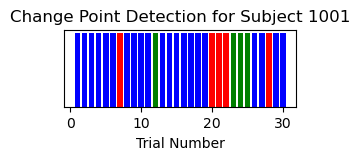

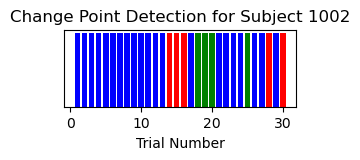

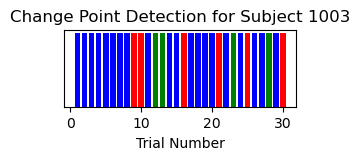

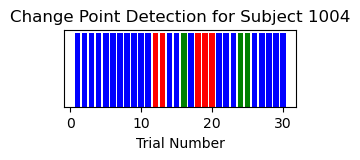

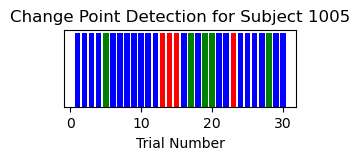

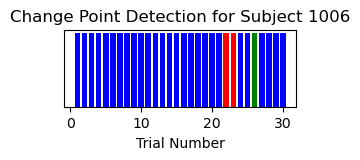

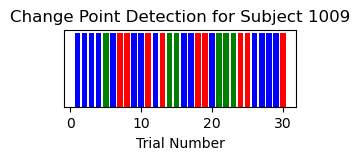

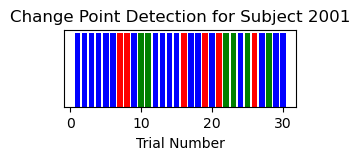

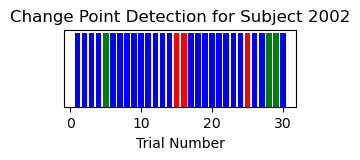

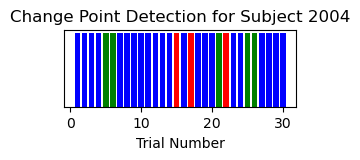

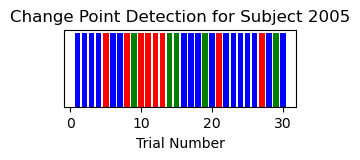

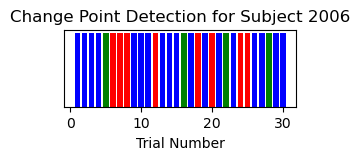

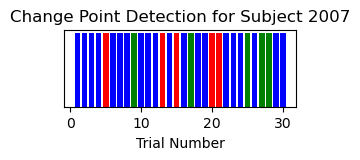

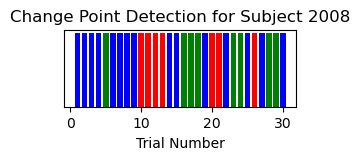

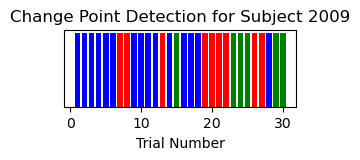

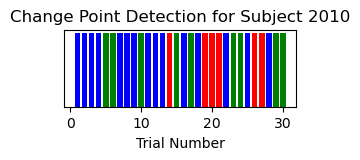

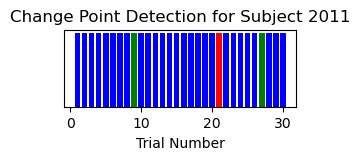

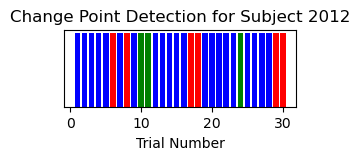

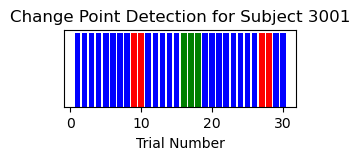

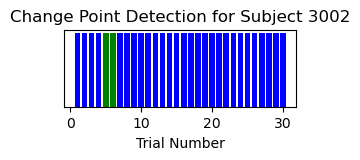

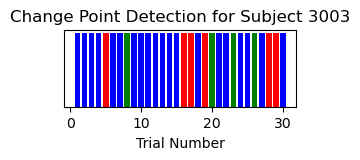

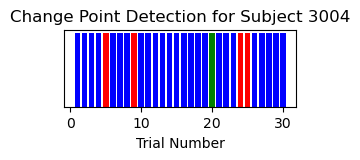

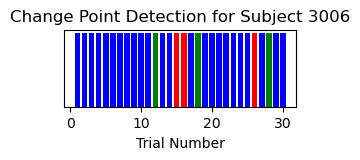

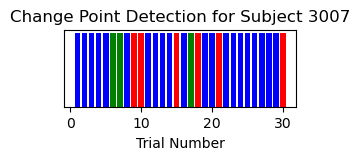

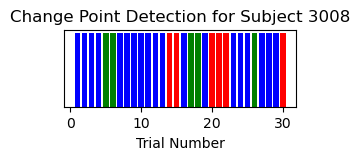

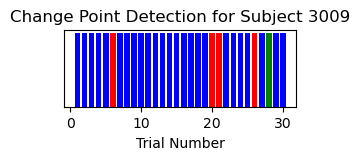

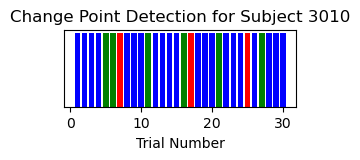

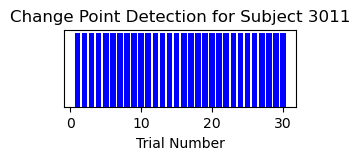

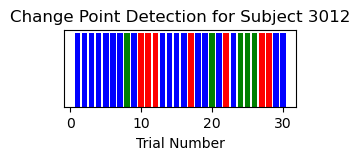

In [438]:
for i in range(0,29): # make dynamic for number of subjects
    subject = i
    colors = {"learning": "green", "nothing": "blue", "fatigued": "red"}
    # colors = {"learning": "green", "nothing": "blue"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,1))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {small_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()